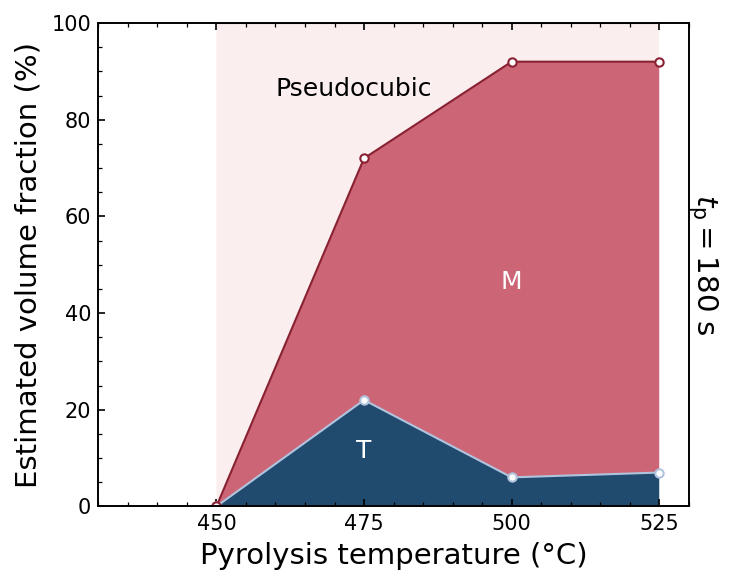

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
temp = np.array([450, 475, 500, 525])
# Estimated values from image
vol_T = np.array([0, 22, 6, 7])
vol_M = np.array([0, 50, 86, 85]) # T+M sum to total curve
vol_Total = vol_T + vol_M # Should go to ~90-95%
vol_Pseudo = 100 - vol_Total # Remainder

# Correct logic for stackplot: layers stack on top of each other
# Layer 1: T (Blue)
y1 = vol_T
# Layer 2: M (Red) - goes on top of T
y2 = vol_M
# Layer 3: Pseudocubic (Pink) - remainder
y3 = vol_Pseudo

# --- Plotting ---
fig, ax = plt.subplots(figsize=(5, 4), dpi=150)

# Stackplot
ax.stackplot(temp, y1, y2, y3, colors=['#204a6e', '#cc6677', '#fbeeee'], labels=['T', 'M', 'Pseudocubic'])

# Add lines/points on boundaries
ax.plot(temp, y1, 'o-', color='#b0c4de', markerfacecolor='white', markersize=4, lw=1)
ax.plot(temp, y1 + y2, 'o-', color='#882233', markerfacecolor='white', markersize=4, lw=1)
ax.plot(temp, np.ones_like(temp)*100, '-', color='#204a6e', lw=1) # Top border

# Labels inside areas
ax.text(475, 10, 'T', color='white', ha='center', fontsize=12)
ax.text(500, 45, 'M', color='white', ha='center', fontsize=12)
ax.text(460, 85, 'Pseudocubic', color='black', fontsize=12)

# Styling
ax.set_xlabel('Pyrolysis temperature (°C)', fontsize=14)
ax.set_ylabel('Estimated volume fraction (%)', fontsize=14)
ax.set_xlim(430, 530)
ax.set_ylim(0, 100)
ax.set_xticks([450, 475, 500, 525])

# Ticks
ax.minorticks_on()
ax.tick_params(direction='in', which='both', top=True, right=True)

# Right axis label (Time)
ax2 = ax.twinx()
ax2.set_ylabel(r'$t_{\mathrm{p}} = 180$ s', fontsize=14, rotation=270, labelpad=15)
ax2.set_yticks([])

plt.tight_layout()
plt.show()
